## **Tipos de regresión**
* Lineal (simple y múltiple)
* Polinómica
* Logística

---

## **Regresión Logística**

* Para problemas de clasificación binaria (valores 0 y 1).
* La salida es la probabilidad de pertenecer a una clase (normalmente $P(y = 1)$).
$$P(Y = 1) = \frac{1}{1 + e^{-(b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n)}}$$
* $P(Y = 1)$ probabilidad de que $Y$ sea igual a 1.
* e es la base del logaritmo natural (aprox. 2.71828).
* $b_0, b_1, \dots, b_n$ los coeficientes a estimar.
* $x_1, x_2, \dots, x_n$ las variables independientes.

---

Usaremos estos datos:
* Horas ($x$): $[1, 2, 3, 4, 5, 6]$
* Aprobado ($y$): $[0, 0, 0, 1, 1, 1]$ (Los que estudian 4 horas o más aprueban).

---

**1. Nivel Nativo (Python + NumPy)**

Implementamos la función **Sigmoide** y el gradiente para actualizar los pesos manualmente.

In [ ]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z)) # Función sigmoide para probabilidad

x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([0, 0, 0, 1, 1, 1])

# Inicialización
w, b = 0.0, 0.0
lr = 0.1

for _ in range(1000):
    z = w * x + b
    y_pred = sigmoid(z)
    # Gradientes
    dw = np.mean((y_pred - y) * x)
    db = np.mean(y_pred - y)
    w -= lr * dw
    b -= lr * db

# Predicción para 3.5 horas
prob = sigmoid(w * 3.5 + b)
print(f"Probabilidad de aprobar (3.5h): {prob:.2f}")

Probabilidad de aprobar (3.5h): 0.57


---
**2. TensorFlow (Nivel Bajo)**

Usamos `BinaryCrossentropy` para medir el error de clasificación y optimizamos los coeficientes $b_n$.

In [ ]:
import tensorflow as tf

x = tf.constant([1., 2., 3., 4., 5., 6.])
y = tf.constant([0., 0., 0., 1., 1., 1.])

w = tf.Variable(0.0)
b = tf.Variable(0.0)
opt = tf.optimizers.SGD(0.1)

for _ in range(500):
    with tf.GradientTape() as tape:
        y_pred = tf.sigmoid(w * x + b) # P(Y=1)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, y_pred))
    grads = tape.gradient(loss, [w, b])
    opt.apply_gradients(zip(grads, [w, b]))

pred = tf.sigmoid(w * 3.5 + b)
print(f"Probabilidad TF: {pred.numpy():.2f}")

Probabilidad TF: 0.58


---
**3. Keras (Red Neuronal)**

Utilizamos una sola neurona con activación sigmoid, que es el estándar para clasificación binaria.

In [ ]:
from tensorflow import keras
import numpy as np

x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([0, 0, 0, 1, 1, 1])

model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(1,), activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(x, y, epochs=1000, verbose=0)

# Predicción
print(f"Predicción Keras (3.5h): {model.predict(np.array([3.5]).reshape(-1, 1))[0][0]:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicción Keras (3.5h): 0.72


---
**4. Scikit-Learn (Analítico)**

Es el método más directo para estimar los coeficientes $b_0, b_1 \dots b_n$.

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

x = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
y = np.array([0, 0, 0, 1, 1, 1])

model = LogisticRegression()
model.fit(x, y)

# Obtener probabilidad de la clase 1 (Aprobado)
pred_prob = model.predict_proba([[3.5]])[0][1]

print(f"Coeficientes: {model.coef_}, Intersección: {model.intercept_}") #
print(f"Probabilidad Sklearn (3.5h): {pred_prob:.2f}")

Coeficientes: [[1.12069525]], Intersección: [-3.9223039]
Probabilidad Sklearn (3.5h): 0.50


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generar un rango de valores para graficar la curva sigmoide
x_plot = np.linspace(0, 7, 300).reshape(-1, 1)
y_proba_plot = model.predict_proba(x_plot)[:, 1] # Probabilidad de la clase 1

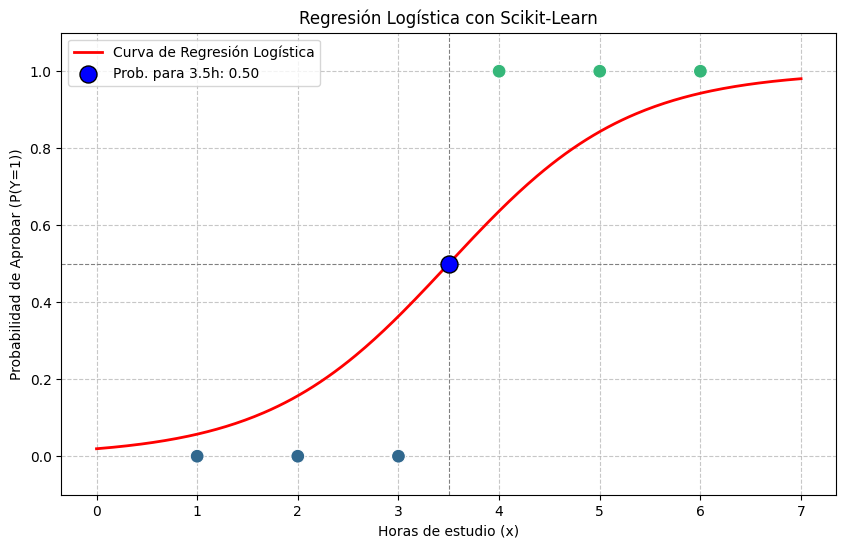

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x.flatten(), y=y, hue=y, palette='viridis', s=100, zorder=5, legend=False)
plt.plot(x_plot, y_proba_plot, color='red', linewidth=2, label='Curva de Regresión Logística')

# Marcar la predicción para 3.5 horas
plt.scatter(3.5, pred_prob, color='blue', s=150, marker='o', edgecolor='black', zorder=6, label=f'Prob. para 3.5h: {pred_prob:.2f}')
plt.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=pred_prob, color='gray', linestyle='--', linewidth=0.8)

plt.title('Regresión Logística con Scikit-Learn')
plt.xlabel('Horas de estudio (x)')
plt.ylabel('Probabilidad de Aprobar (P(Y=1))')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(-0.1, 1.1) # Extender límites para mejor visualización
plt.show()

---

## **Método de Máxima Verosimilitud**

* Se emplea para calcular los coeficientes en la regresión logística.
* Se basa en la función de verosimilitud, la cual mide la probabilidad de que la clase sea 1 dados los atributos $x$:

$$L(b_0, b_1, \dots, b_n) = \prod_{i=1}^{N} P(Y_i)^{y_i} \cdot (1 - P(Y_i))^{1-y_i}$$

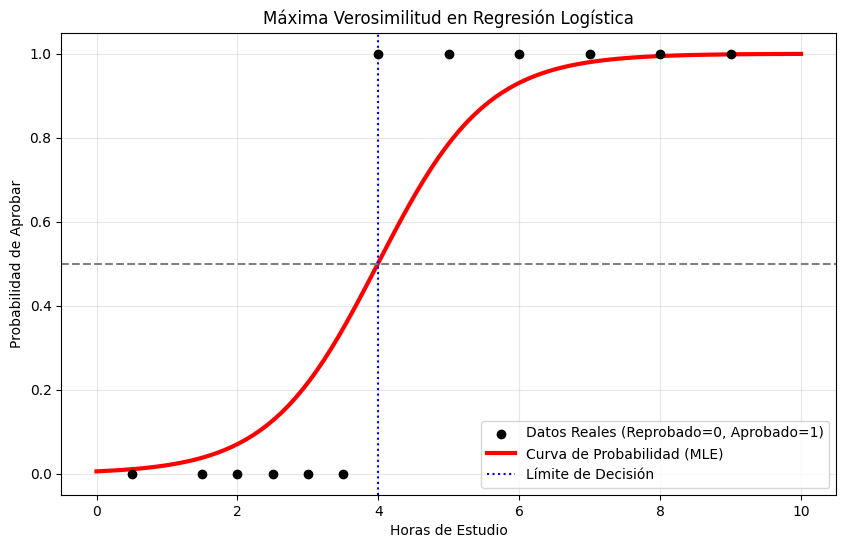

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Datos: Horas de estudio vs Aprobado (0 o 1)
X = np.array([0.5, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]).reshape(-1, 1)
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# 2. Entrenar modelo (Usa Máxima Verosimilitud internamente)
modelo = LogisticRegression()
modelo.fit(X, y)

# 3. Crear datos para la curva suave
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
probabilidades = modelo.predict_proba(X_test)[:, 1]

# 4. Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', zorder=20, label='Datos Reales (Reprobado=0, Aprobado=1)')
plt.plot(X_test, probabilidades, color='red', linewidth=3, label='Curva de Probabilidad (MLE)')

# Línea de decisión (Umbral de 0.5)
plt.axhline(0.5, color='gray', linestyle='--')
plt.axvline(-modelo.intercept_/modelo.coef_, color='blue', linestyle=':', label='Límite de Decisión')

plt.title('Máxima Verosimilitud en Regresión Logística')
plt.xlabel('Horas de Estudio')
plt.ylabel('Probabilidad de Aprobar')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()